In [55]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline,make_pipeline
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import joblib  # Used to save our final production workflow file


In [56]:
df=pd.read_csv("AB_NYC_2019.CSV")

df=df.drop(columns=["host_id","id","last_review","host_name","name"])
df.columns
df.head(2)
df.info()
df.isnull().sum()

ParserError: Error tokenizing data. C error: out of memory

   price  log_price
0    149   5.010635
1    225   5.420535
2    150   5.017280
3     89   4.499810
4     80   4.394449


np.float64(0.11951457335231432)

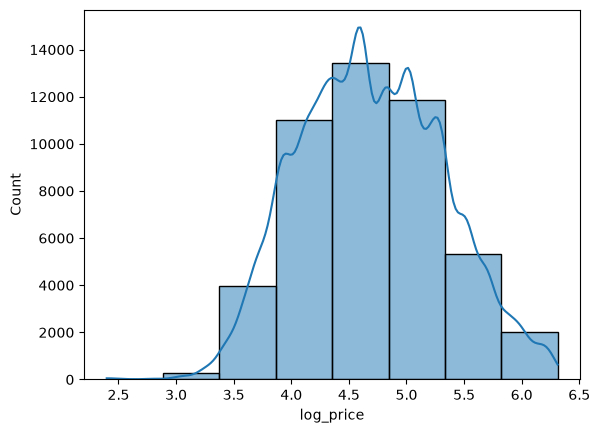

In [57]:
# Fill missing reviews with 0.0
df['reviews_per_month'] = df['reviews_per_month'].fillna(0.0)


# Keep only listings where the price is greater than 0
df = df[df['price'] > 0]
price_cap=df['price'].quantile(0.99)
df=df[df["price"]<=price_cap]
df['log_price'] = np.log1p(df['price'])
print(df[['price','log_price']].head())
sns.histplot(data=df, x="log_price", binwidth=0.50, kde=True)
df["log_price"].skew()


In [58]:

# Count listings that originally had minimum_nights > 365

count_capped = (df['minimum_nights'] > 365).sum()

print("Number of listings capped at 365:", count_capped)

df['minimum_nights'] = df['minimum_nights'].clip(upper=365)
print(df['minimum_nights'].max())
df.shape
df.columns
df.isnull().sum()
df.head()

Number of listings capped at 365: 0
365


,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,log_price
0,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365,5.010635
1,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355,5.420535
2,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,0.00,1,365,5.017280
3,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194,4.499810
4,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0,4.394449


In [59]:
from sklearn.model_selection import train_test_split

# Split the data while features are still raw text
X_train, X_test, y_train, y_test = train_test_split(df.drop(columns=["price","log_price","neighbourhood"]),df["log_price"], test_size=0.2, random_state=42)

print(f"Raw Training data shape: {X_train.shape}")
print(f"Raw Testing data shape: {X_test.shape}")

categorical_cols = ['neighbourhood_group', 'room_type']
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'
)


Raw Training data shape: (38359, 9)
Raw Testing data shape: (9590, 9)


In [60]:
# Define our two pipeline configurations
pipelines = {
    'Decision Tree': Pipeline([('preprocessor', preprocessor), ('regressor', DecisionTreeRegressor(random_state=42, max_depth=12))]),
    'Random Forest': Pipeline([('preprocessor', preprocessor), ('regressor', RandomForestRegressor(random_state=42, n_estimators=100, max_depth=12))])
}

# Train and compare performance
for name, pipe in pipelines.items():
    # Fit the pipeline DIRECTLY on the raw X_train, y_train
    pipe.fit(X_train, y_train)
    
    # Check for overfitting by calculating train score vs test score
    train_preds = np.expm1(pipe.predict(X_train))
    test_preds = np.expm1(pipe.predict(X_test))
    
    real_y_train = np.expm1(y_train)
    real_y_test = np.expm1(y_test)
    
    train_mae = mean_absolute_error(real_y_train, train_preds)
    test_mae = mean_absolute_error(real_y_test, test_preds)
    test_r2 = r2_score(real_y_test, test_preds)
    
    print(f"=== {name} Performance ===")
    print(f"Train Error (MAE): ${train_mae:.2f}")
    print(f"Test Error (MAE):  ${test_mae:.2f}")
    print(f"Test R² Score:     {test_r2:.2f}")
    
    # Overfitting diagnosis checklist rule
    if train_mae < (test_mae * 0.7):
        print("⚠️ Diagnosis: Model shows signs of Overfitting. It performs significantly better on training data than testing data.")
    else:
        print("✅ Diagnosis: Model generalization looks balanced.")
    print("-" * 40)


=== Decision Tree Performance ===
Train Error (MAE): $34.08
Test Error (MAE):  $41.79
Test R² Score:     0.41
✅ Diagnosis: Model generalization looks balanced.
----------------------------------------
=== Random Forest Performance ===
Train Error (MAE): $33.87
Test Error (MAE):  $38.72
Test R² Score:     0.50
✅ Diagnosis: Model generalization looks balanced.
----------------------------------------


In [62]:
import joblib

# Assuming 'Random Forest' is your winning model pipeline
best_pipeline = pipelines['Random Forest']

# Save the unified pipeline using joblib
joblib.dump(best_pipeline, 'airbnb_model_pipeline.pkl',compress=3)


print("🎉 Success! The final preprocessing workflow and model are saved using joblib.")

🎉 Success! The final preprocessing workflow and model are saved using joblib.
